In [1]:
import pickle
import inspect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Imports successful")

Imports successful


In [2]:
data = pd.read_csv("heart.csv")

print("Dataset shape:", data.shape)
display(data.head())

Dataset shape: (297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [3]:
print("Dataset information:")
data.info()

print("\nMissing values:")
print(data.isnull().sum())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB

Missing values:
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0


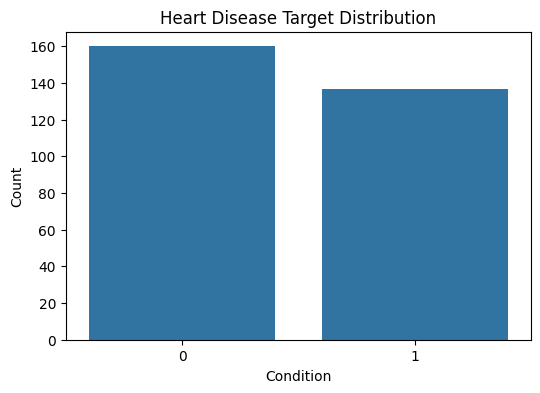

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x="condition", data=data)
plt.title("Heart Disease Target Distribution")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.show()

In [5]:
features = ["age", "sex", "cp", "chol", "thalach"]
target = "condition"

X = data[features]
y = data[target]

print("Input shape:", X.shape)
print("Output shape:", y.shape)
print("Features:", features)

Input shape: (297, 5)
Output shape: (297,)
Features: ['age', 'sex', 'cp', 'chol', 'thalach']


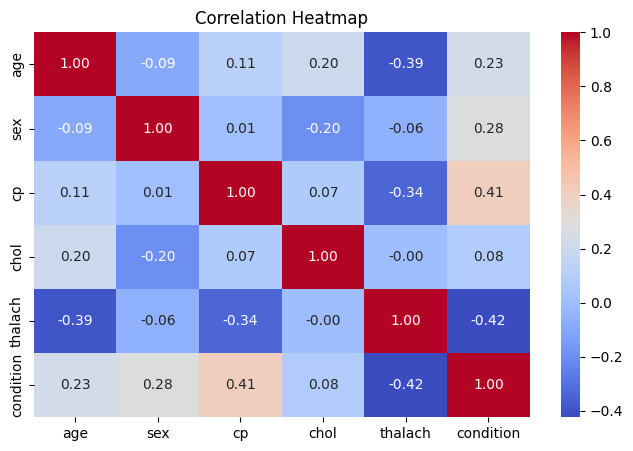

In [6]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    data[features + [target]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (237, 5)
Testing shape: (60, 5)


In [8]:
# Compatible with both older and newer scikit-learn versions.
ada_params = inspect.signature(AdaBoostClassifier).parameters

if "algorithm" in ada_params:
    boosting_model = AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.8,
        algorithm="SAMME",
        random_state=42
    )
else:
    boosting_model = AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.8,
        random_state=42
    )

boosting_model.fit(X_train, y_train)

print("Boosting model trained successfully")
print("scikit-learn version:", __import__("sklearn").__version__)

Boosting model trained successfully
scikit-learn version: 1.5.2


In [9]:
y_pred = boosting_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Boosting Accuracy: {accuracy:.2%}")

Boosting Accuracy: 76.67%


In [10]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.78      0.78        32
           1       0.75      0.75      0.75        28

    accuracy                           0.77        60
   macro avg       0.77      0.77      0.77        60
weighted avg       0.77      0.77      0.77        60



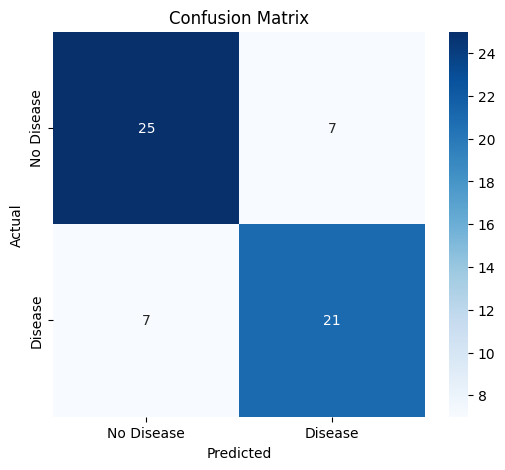

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

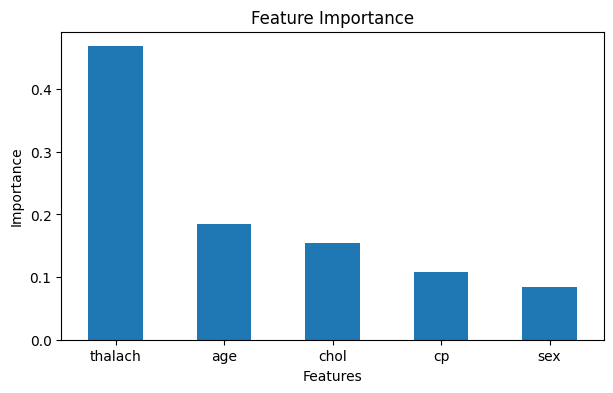

thalach    0.468286
age        0.184809
chol       0.153780
cp         0.108579
sex        0.084545
dtype: float64


In [12]:
importance = pd.Series(
    boosting_model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
importance.plot(kind="bar")
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=0)
plt.show()

print(importance)

In [13]:
# Verification checks
assert len(data) == 297
assert X.shape == (297, 5)
assert y.shape == (297,)
assert X_train.shape == (237, 5)
assert X_test.shape == (60, 5)
assert len(y_pred) == len(y_test)

print("All verification checks passed.")
print(f"Final test accuracy: {accuracy:.2%}")

All verification checks passed.
Final test accuracy: 76.67%


In [14]:
with open("heart_disease_boosting.pkl", "wb") as file:
    pickle.dump(boosting_model, file)

print("Boosting model saved successfully")

Boosting model saved successfully


In [15]:
# Final saved-model verification
with open("heart_disease_boosting.pkl", "rb") as file:
    saved_model = pickle.load(file)

saved_predictions = saved_model.predict(X_test)

assert np.array_equal(saved_predictions, y_pred)

print("Saved model loaded successfully.")
print(f"Saved model accuracy: {accuracy_score(y_test, saved_predictions):.2%}")
print("Model verification passed.")

Saved model loaded successfully.
Saved model accuracy: 76.67%
Model verification passed.
